In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

rfm = pd.read_csv("../data/rfm_churn.csv")

X = rfm[["frequency", "monetary"]]   # recency excluded — data leakage, see Day 5 notes
y = rfm["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [2]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)
print("Model trained")

Model trained


In [3]:
from sklearn.metrics import classification_report, roc_auc_score

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_preds))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_probs))

              precision    recall  f1-score   support

           0       0.44      0.63      0.52      7621
           1       0.63      0.44      0.52     11051

    accuracy                           0.52     18672
   macro avg       0.54      0.54      0.52     18672
weighted avg       0.55      0.52      0.52     18672

Random Forest ROC-AUC: 0.5636772079055022


In [4]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight="balanced")
lr.fit(X_train, y_train)
lr_probs = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, lr_probs))
print("Random Forest ROC-AUC:      ", roc_auc_score(y_test, rf_probs))

Logistic Regression ROC-AUC: 0.5100046638747853
Random Forest ROC-AUC:       0.5636772079055022


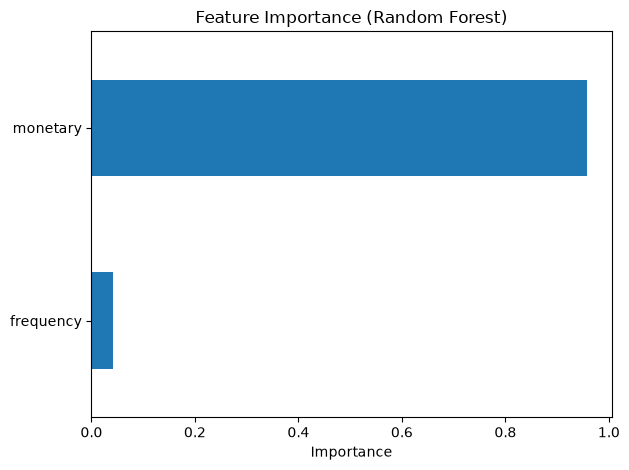

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
importances.plot(kind="barh", title="Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../dashboard/feature_importance.png", dpi=150)
plt.show()

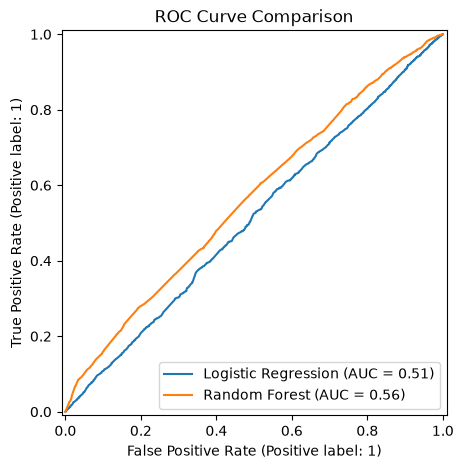

In [6]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, lr_probs, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_probs, name="Random Forest", ax=ax)
plt.title("ROC Curve Comparison")
plt.savefig("../dashboard/roc_comparison.png", dpi=150)
plt.show()

In [7]:
import joblib

joblib.dump(rf, "../src/churn_model.pkl")
print("Model saved to src/churn_model.pkl")

Model saved to src/churn_model.pkl


## Day 6 Notes — Model Comparison
- Logistic Regression ROC-AUC: 0.51
- Random Forest ROC-AUC: 0.56 (marginal improvement)
- Frequency and monetary alone are weak churn predictors — most customers are
  one-time buyers (from Day 4 EDA), so frequency has little variance to learn from.
- This is a genuine limitation of pure RFM features on this dataset; a production
  system would need richer signals (browsing behavior, support tickets, marketing
  engagement) not available here.
- Proceeding with Random Forest as the marginally better model; the real value-add
  of this project comes from the sentiment layer (Days 8-9) which adds an explanatory
  signal RFM alone can't capture.